In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib.colors import SymLogNorm
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from scipy.stats.qmc import Sobol

In [2]:
#Function 1
input_data_1 = np.load('initial_data/function_1/initial_inputs.npy')
output_data_1 = np.load('initial_data/function_1/initial_outputs.npy')
# include new data from week 1
input_data_1 = np.append(input_data_1, [[0.838384, 0.767677]], axis=0)
output_data_1 = np.append(output_data_1, -6.893705068847273e-45)
# include new data from week 2
input_data_1 = np.append(input_data_1, [[0.766917, 0.775188]], axis=0)
output_data_1 = np.append(output_data_1, 7.549535198911049e-29)
# include new data from week 3
input_data_1 = np.append(input_data_1, [[0.818182, 0.678322]], axis=0)
output_data_1 = np.append(output_data_1, -4.195357984960884e-28)
# include new data from week 4
input_data_1 = np.append(input_data_1, [[0.696429, 0.791667]], axis=0)
output_data_1 = np.append(output_data_1, -3.5814423788043363e-22)
# include new data from week 5
input_data_1 = np.append(input_data_1, [[0.500000, 0.500000]], axis=0)
output_data_1 = np.append(output_data_1, 2.6752879910742468e-9)
# include new data from week 6
input_data_1 = np.append(input_data_1, [[0.392857, 0.361607]], axis=0)
output_data_1 = np.append(output_data_1, -0.00026568694388677744)
# include new data from week 7
input_data_1 = np.append(input_data_1, [[0.650000, 0.550000]], axis=0)
output_data_1 = np.append(output_data_1, -0.000032362397142762835)
# include new data from week 8
input_data_1 = np.append(input_data_1, [[0.579861, 0.517361]], axis=0)
output_data_1 = np.append(output_data_1, 1.1198419648596327e-11)
# include new data from week 9
input_data_1 = np.append(input_data_1, [[0.535604, 0.507740]], axis=0)
output_data_1 = np.append(output_data_1, 8.123897191749067e-16)
# include new data from week 10
input_data_1 = np.append(input_data_1, [[0.500000, 0.600000]], axis=0)
output_data_1 = np.append(output_data_1, 3.108406981123136e-13)
# include new data from week 11
input_data_1 = np.append(input_data_1, [[0.463659, 0.466165]], axis=0)
output_data_1 = np.append(output_data_1, 0.000059634613302091375)

In [3]:
print(input_data_1)
print(input_data_1.shape)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.838384   0.767677  ]
 [0.766917   0.775188  ]
 [0.818182   0.678322  ]
 [0.696429   0.791667  ]
 [0.5        0.5       ]
 [0.392857   0.361607  ]
 [0.65       0.55      ]
 [0.579861   0.517361  ]
 [0.535604   0.50774   ]
 [0.5        0.6       ]
 [0.463659   0.466165  ]]
(21, 2)


In [4]:
print(output_data_1)
print(output_data_1.shape)
print(np.sort(output_data_1))

[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -6.89370507e-045  7.54953520e-029
 -4.19535798e-028 -3.58144238e-022  2.67528799e-009 -2.65686944e-004
 -3.23623971e-005  1.11984196e-011  8.12389719e-016  3.10840698e-013
  5.96346133e-005]
(21,)
[-3.60606264e-003 -2.65686944e-004 -3.23623971e-005 -3.58144238e-022
 -4.19535798e-028 -6.89370507e-045 -2.15924904e-054 -2.08909327e-091
  3.34177101e-124  3.60677119e-081  1.32267704e-079  6.22985647e-048
  1.03307824e-046  2.53500115e-040  7.54953520e-029  7.71087511e-016
  8.12389719e-016  3.10840698e-013  1.11984196e-011  2.67528799e-009
  5.96346133e-005]


In [5]:
### The outcome from week 11 is the best so far
# Using the models prediction with same configuration for this round

[2.67528799e-09 1.11984196e-11 3.10840698e-13 5.96346133e-05]
[0.425    0.429545]


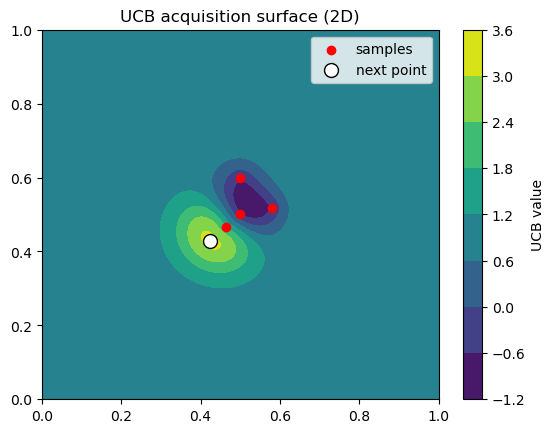

In [6]:
noise_assumption = 1e-15

rbf_lengthscale = 0.07 # from 0.07 to 0.4

#Acquisition function parameter
beta = 0.9 # from 0.9 to 0.3

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)
X = input_data_1
Y = output_data_1

# manually remove noise
mask = Y >= noise_assumption
X = X[mask]
Y = Y[mask]
print(Y)

Y = (Y - Y.mean()) / Y.std() #standardise data to account for very small values
#Initialise grid for plots
grid_x = np.linspace(0, 1, len(output_data_1)**2)
grid_y = np.linspace(0, 1, len(output_data_1)**2)
xx, yy = np.meshgrid(grid_x, grid_y)
x_grid = np.c_[xx.ravel(), yy.ravel()]

model = GaussianProcessRegressor(kernel = kernel)

#Fit the GP model
model.fit(X, Y)

#Calculate the mean and standard deviation
post_mean, post_std = model.predict(x_grid, return_std=True)

# UCB acquisition
acquisition_function = post_mean + beta * post_std

"""
#EI acquisition
xi = 0.01
f_best = np.max(Y)
improvement = post_mean - f_best - xi
z = improvement / post_std
acquisition_function = improvement * norm.cdf(z) + post_std * norm.pdf(z)
acquisition_function[post_std == 0.0] = 0.0
"""
X_next = x_grid[np.argmax(acquisition_function)]

print(np.round(X_next, decimals=6))

# -----------------------
# 8. Plot UCB surface
# -----------------------
plt.contourf(xx, yy, acquisition_function.reshape(xx.shape))
plt.colorbar(label="UCB value")
plt.scatter(X[:,0], X[:,1], c='red', label="samples")
plt.scatter(X_next[0], X_next[1], c='white', edgecolor='black', s=100, label="next point")
plt.legend()
plt.title("UCB acquisition surface (2D)")
plt.show()

[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.818182   0.939394  ]
 [0.621053   0.987218  ]
 [0.215981   0.660104  ]
 [0.684524   0.309524  ]
 [0.830769   0.215385  ]
 [0.59375    0.46875   ]
 [0.819608   0.439216  ]
 [0.607639   0.232639  ]
 [0.739938   0.325077  ]
 [0.727778   0.058333  ]
 [0.661654   0.360902  ]]
(21, 2)
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.05218796  0.35089095
 -0.11245845  0.68358114  0.11453265  0.05881646  0.07446012  0.11868073
  0.48262614  0.5858451   0.37216679]
(21,)
[-0.11245845 -0.06562362 -0.01385762  0.02310555  0.03874902  0.05218796
  0.05881646  0.07446012  0.11453265  0.11868073  0.21496451  0.24461934
  0.29399291  0.35089095  0.37216679  0.42058624  0.48262

/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


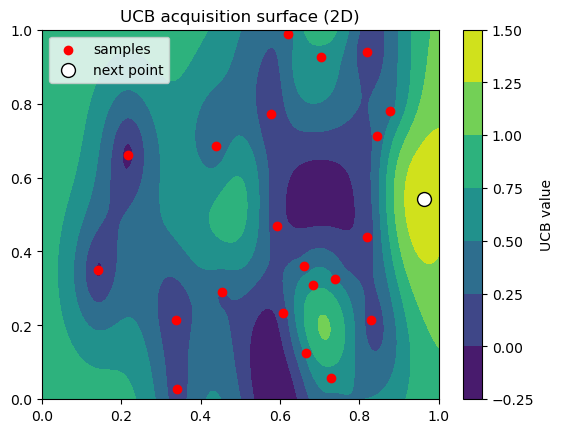

In [31]:
#Function 2
# Outcome from week 11 was poor, progress from previous weeks stopped
# Now using RBF + ARD to improve performance
input_data_2 = np.load('initial_data/function_2/initial_inputs.npy')
output_data_2 = np.load('initial_data/function_2/initial_outputs.npy')
# include new data from week 1
input_data_2 = np.append(input_data_2, [[0.818182, 0.939394]], axis=0)
output_data_2 = np.append(output_data_2, 0.052187964293633496)
# include new data from week 2
input_data_2 = np.append(input_data_2, [[0.621053, 0.987218]], axis=0)
output_data_2 = np.append(output_data_2, 0.3508909522243821)
# include new data from week 3
input_data_2 = np.append(input_data_2, [[0.215981, 0.660104]], axis=0)
output_data_2 = np.append(output_data_2, -0.11245844564734742)
# include new data from week 4
input_data_2 = np.append(input_data_2, [[0.684524, 0.309524]], axis=0)
output_data_2 = np.append(output_data_2, 0.6835811441905567)
# include new data from week 5
input_data_2 = np.append(input_data_2, [[0.830769, 0.215385]], axis=0)
output_data_2 = np.append(output_data_2, 0.11453265300325303)
# include new data from week 6
input_data_2 = np.append(input_data_2, [[0.593750, 0.468750]], axis=0)
output_data_2 = np.append(output_data_2, 0.05881646054061138)
# include new data from week 7
input_data_2 = np.append(input_data_2, [[0.819608, 0.439216]], axis=0)
output_data_2 = np.append(output_data_2, 0.07446012178022374)
# include new data from week 8
input_data_2 = np.append(input_data_2, [[0.607639, 0.232639]], axis=0)
output_data_2 = np.append(output_data_2, 0.11868072962416833)
# include new data from week 9
input_data_2 = np.append(input_data_2, [[0.739938, 0.325077]], axis=0)
output_data_2 = np.append(output_data_2, 0.48262613931488196)
# include new data from week 10
input_data_2 = np.append(input_data_2, [[0.727778, 0.058333]], axis=0)
output_data_2 = np.append(output_data_2, 0.5858451015318697)
# include new data from week 11
input_data_2 = np.append(input_data_2, [[0.661654, 0.360902]], axis=0)
output_data_2 = np.append(output_data_2, 0.3721667879825815)


print(input_data_2)
print(input_data_2.shape)
print(output_data_2)
print(output_data_2.shape)
print(np.sort(output_data_2))

real_noise_std = 1e-6
noise_assumption = 1e-6
rbf_lengthscale = np.ones(2)

#Acquisition function parameter
beta = 0.96 # from 3 to 0.96

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(0.1, 0.5))
model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

X = input_data_2
Y = output_data_2

#Initialise grid for plots
grid_x = np.linspace(0, 1, len(output_data_2)**2)
grid_y = np.linspace(0, 1, len(output_data_2)**2)
xx, yy = np.meshgrid(grid_x, grid_y)
x_grid = np.c_[xx.ravel(), yy.ravel()]

model = GaussianProcessRegressor(kernel = kernel)

#Fit the GP model
model.fit(X, Y)

#Calculate the mean and standard deviation
post_mean, post_std = model.predict(x_grid, return_std=True)

# UCB acquisition
acquisition_function = post_mean + beta * post_std

X_next = x_grid[np.argmax(acquisition_function)]

print('Next: ', (np.round(X_next, decimals=6)))

# -----------------------
# 8. Plot UCB surface
# -----------------------
plt.contourf(xx, yy, acquisition_function.reshape(xx.shape))
plt.colorbar(label="UCB value")
plt.scatter(X[:,0], X[:,1], c='red', label="samples")
plt.scatter(X_next[0], X_next[1], c='white', edgecolor='black', s=100, label="next point")
plt.legend()
plt.title("UCB acquisition surface (2D)")
plt.show()

In [34]:
# Function 3
# Outcome from week 11 is poor, guess the model has converged
# Staying exploitative in this round, using same configuration as last week

input_data_3 = np.load('initial_data/function_3/initial_inputs.npy')
output_data_3 = np.load('initial_data/function_3/initial_outputs.npy')
# include new data from week 1
input_data_3 = np.append(input_data_3, [[0.414145, 0.390256, 0.511599]], axis=0)
output_data_3 = np.append(output_data_3, -0.010572017488314756)
# include new data from week 2
input_data_3 = np.append(input_data_3, [[0.486811, 0.675060, 0.592334]], axis=0)
output_data_3 = np.append(output_data_3, -0.050701081879245206)
# include new data from week 3
input_data_3 = np.append(input_data_3, [[0.394017, 0.116418, 0.453656]], axis=0)
output_data_3 = np.append(output_data_3, -0.056130798616076505)
# include new data from week 4
input_data_3 = np.append(input_data_3, [[0.436577, 0.098114, 0.081182]], axis=0)
output_data_3 = np.append(output_data_3, -0.08169605401754566)
# include new data from week 5
input_data_3 = np.append(input_data_3, [[0.365383, 0.487012, 0.453596]], axis=0)
output_data_3 = np.append(output_data_3, -0.023060371524595977)
# include new data from week 6
input_data_3 = np.append(input_data_3, [[0.338396, 0.308780, 0.464341]], axis=0)
output_data_3 = np.append(output_data_3, -0.023805401625752315)
# include new data from week 7
input_data_3 = np.append(input_data_3, [[0.450221, 0.567673, 0.474983]], axis=0)
output_data_3 = np.append(output_data_3, -0.00046822764843421755)
# include new data from week 8
input_data_3 = np.append(input_data_3, [[0.190780, 0.151583, 0.538816]], axis=0)
output_data_3 = np.append(output_data_3, -0.03842125939629416)
# include new data from week 9
input_data_3 = np.append(input_data_3, [[0.875187, 0.635732, 0.250387]], axis=0)
output_data_3 = np.append(output_data_3, -0.10134712489632021)
# include new data from week 10
input_data_3 = np.append(input_data_3, [[0.463099, 0.496023, 0.473688]], axis=0)
output_data_3 = np.append(output_data_3, 0.008818623635985325)
# include new data from week 11
input_data_3 = np.append(input_data_3, [[0.471048, 0.519750, 0.432684]], axis=0)
output_data_3 = np.append(output_data_3, -0.02169733316002734)

print(input_data_3)
print(input_data_3.shape)
print(output_data_3)
print(output_data_3.shape)
print(np.sort(output_data_3))

real_noise_std = 1e-10 
noise_assumption = 1e-10
rbf_lengthscale = 0.1 # from 0.2 to 0.1

#Acquisition function parameter
beta = 0.5 # from 0.9 to 0.5

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

X = input_data_3
y = output_data_3 # sample already negated to transform from minimisation to maximisation problem
Y = (y - y.mean()) / y.std() # scale to support tiny numbers

model = GaussianProcessRegressor(kernel = kernel)

#Fit the GP model
model.fit(X, Y)

# UCB acquisition
def acquisition(x):
    x = x.reshape(1, -1)
    post_mean, post_std = model.predict(x, return_std=True)
    return post_mean + beta * post_std


# Find Next Point
def propose_next(gp, bounds, n_restarts=5):
    best_x = None
    best_val = -np.inf

    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=3)

        res = minimize(
            lambda x: -acquisition(x),  # maximise UCB
            x0=x0,
            bounds=bounds,
            method="L-BFGS-B"
        )

        val = acquisition(res.x)

        if val > best_val:
            best_val = val
            best_x = res.x

    return np.round(best_x, decimals=6)

# Get Next Point
bounds = [(0, 1), (0, 1), (0, 1)]
x_next = propose_next(model, bounds)
print("Next proposed input:", x_next)


[[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.91977134]
 [0.74691195 0.28419631 0.22629985]
 [0.17047699 0.6970324  0.14916943]
 [0.22054934 0.29782524 0.34355534]
 [0.66601366 0.67198515 0.2462953 ]
 [0.04680895 0.23136024 0.77061759]
 [0.60009728 0.72513573 0.06608864]
 [0.96599485 0.86111969 0.56682913]
 [0.414145   0.390256   0.511599  ]
 [0.486811   0.67506    0.592334  ]
 [0.394017   0.116418   0.453656  ]
 [0.436577   0.098114   0.081182  ]
 [0.365383   0.487012   0.453596  ]
 [0.338396   0.30878    0.464341  ]
 [0.450221   0.567673   0.474983  ]
 [0.19078    0.151583   0.538816  ]
 [0.875187   0.635732   0.250387  ]
 [0.463099   0.496023   0.473688  ]
 [0.471048   0.51975    0.432684  ]]
(26, 3)
[-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.048

In [42]:
# Function 4
# Outcome from week 11 yielded second best.
# In this round, I am evaluating the accuracy of NN ensemble surrogate and tunning for improved performance
input_data_4 = np.load('initial_data/function_4/initial_inputs.npy')
output_data_4 = np.load('initial_data/function_4/initial_outputs.npy')
# include new data from week 1
input_data_4 = np.append(input_data_4, [[0.383229, 0.487977, 0.445785, 0.398437]], axis=0)
output_data_4 = np.append(output_data_4, -1.590305706105521)
# include new data from week 2
input_data_4 = np.append(input_data_4, [[0.400989, 0.278541, 0.491673, 0.336468]], axis=0)
output_data_4 = np.append(output_data_4, -2.3158733786992047)
# include new data from week 3
input_data_4 = np.append(input_data_4, [[0.409478, 0.391879, 0.282717, 0.415204]], axis=0)
output_data_4 = np.append(output_data_4, -1.2770762561275926)
# include new data from week 4
input_data_4 = np.append(input_data_4, [[0.387895, 0.389004, 0.382921, 0.398504]], axis=0)
output_data_4 = np.append(output_data_4, -0.0542073695661176)
# include new data from week 5
input_data_4 = np.append(input_data_4, [[0.362165, 0.356766, 0.401945, 0.493966]], axis=0)
output_data_4 = np.append(output_data_4, -1.0336413904768835)
# include new data from week 6
input_data_4 = np.append(input_data_4, [[0.376422, 0.357202, 0.368252, 0.386731]], axis=0)
output_data_4 = np.append(output_data_4, 0.4633554768256052)
# include new data from week 7
input_data_4 = np.append(input_data_4, [[0.449273, 0.178835, 0.177052, 0.219175]], axis=0)
output_data_4 = np.append(output_data_4, -7.508841002391446)
# include new data from week 8
input_data_4 = np.append(input_data_4, [[0.165697, 0.361160, 0.301309, 0.414112]], axis=0)
output_data_4 = np.append(output_data_4, -4.304762115289975)
# include new data from week 9
input_data_4 = np.append(input_data_4, [[0.354250, 0.284988, 0.320729, 0.368700]], axis=0)
output_data_4 = np.append(output_data_4, -1.3938136521952056)
# include new data from week 10
input_data_4 = np.append(input_data_4, [[0.013453, 0.369740, 0.688545, 0.399713]], axis=0)
output_data_4 = np.append(output_data_4, -12.658410401376198)
# include new data from week 11
input_data_4 = np.append(input_data_4, [[0.377942, 0.342923, 0.413006, 0.399127]], axis=0)
output_data_4 = np.append(output_data_4, 0.39815710552752437)

print(input_data_4)
print(input_data_4.shape)
print(output_data_4)
print(output_data_4.shape)
print(np.sort(output_data_4))

# ============================================================
# CONFIG
# ============================================================

INPUT_DIM = (input_data_4.shape)[1]
NO_DATAPOINTS = (input_data_4.shape)[0]
ENSEMBLE_SIZE = 5
EPOCHS = 300
LR = 1e-2
BETA = 0.96 

torch.manual_seed(42)
np.random.seed(42)

# ============================================================
# HISTORICAL DATA
# ============================================================

X = input_data_4
y = output_data_4

# ============================================================
# NORMALIZATION
# VERY IMPORTANT FOR SMALL DATA
# ============================================================

#normalizing only output because input is already between 0 and 1, stable.
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1))

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

# ============================================================
# SURROGATE NETWORK
# Small network only
# ============================================================

class SurrogateNN(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim, 32),
            nn.ReLU(),

            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# ============================================================
# TRAIN ENSEMBLE
# ============================================================

ensemble = []

for model_idx in range(ENSEMBLE_SIZE):

    model = SurrogateNN(INPUT_DIM)

    optimizer = optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=0
    )

    criterion = nn.MSELoss()

    for epoch in range(EPOCHS):

        model.train()

        optimizer.zero_grad()

        pred = model(X_tensor)

        loss = criterion(pred, y_tensor)

        loss.backward()

        optimizer.step()

    ensemble.append(model)

print("Ensemble training complete.")

# ============================================================
# GENERATE CANDIDATE POOL
# Sobol sampling, better than random sampling due to input range
# ============================================================

sampler = Sobol(
    d=INPUT_DIM,
    scramble=True
)

candidate_pool = sampler.random_base2(m=12)

candidate_tensor = torch.tensor(
    candidate_pool,
    dtype=torch.float32
)

# ============================================================
# PREDICT MEAN + UNCERTAINTY
# ============================================================

predictions = []

with torch.no_grad():

    for model in ensemble:

        model.eval()

        pred = model(candidate_tensor).numpy()

        predictions.append(pred)

predictions = np.stack(predictions, axis=0)

# Ensemble mean and std
mean_pred = predictions.mean(axis=0).flatten()
std_pred = predictions.std(axis=0).flatten()

# ============================================================
# UCB ACQUISITION
# ============================================================

ucb = mean_pred + BETA * std_pred

best_idx = np.argmax(ucb)

best_candidate = candidate_pool[best_idx]

# Convert prediction back to original scale
predicted_value = y_scaler.inverse_transform(
    [[mean_pred[best_idx]]]
)[0][0]

predicted_uncertainty = (
    std_pred[best_idx] * y_scaler.scale_[0]
)

# ============================================================
# OUTPUT NEXT EXPERIMENT
# ============================================================

print("\n===== NEXT POINT TO TEST =====")

print("Candidate:")
print(np.round(best_candidate, decimals=6))

print("\nPredicted objective:")
print(predicted_value)

print("\nModel uncertainty:")
print(predicted_uncertainty)

print("\nUCB score:")
print(ucb[best_idx])


[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0.17034731 

In [38]:
# Function 5
# Week 11 outcome is the best so far
# keeping balanced exploration and exploitation config for this round.
input_data_5 = np.load('initial_data/function_5/initial_inputs.npy')
output_data_5 = np.load('initial_data/function_5/initial_outputs.npy')
# include new data from week 1
input_data_5 = np.append(input_data_5, [[0.240893, 0.843693, 0.902123, 0.884136]], axis=0)
output_data_5 = np.append(output_data_5, 1219.608721581588)
# include new data from week 2
input_data_5 = np.append(input_data_5, [[0.317538, 0.830816, 0.999037, 0.910426]], axis=0)
output_data_5 = np.append(output_data_5, 2026.179144193655)
# include new data from week 3
input_data_5 = np.append(input_data_5, [[0.410003, 0.815208, 1.000000, 0.942739]], axis=0)
output_data_5 = np.append(output_data_5, 2246.3443545869577)
# include new data from week 4
input_data_5 = np.append(input_data_5, [[0.377888, 0.820623, 0.993501, 0.931560]], axis=0)
output_data_5 = np.append(output_data_5, 2102.865502812711)
# include new data from week 5
input_data_5 = np.append(input_data_5, [[0.423608, 0.813848, 1.000000, 0.940625]], axis=0)
output_data_5 = np.append(output_data_5, 2232.0082179726337)
# include new data from week 6
input_data_5 = np.append(input_data_5, [[0.979706, 0.073805, 0.106228, 0.129773]], axis=0)
output_data_5 = np.append(output_data_5, 138.68406118920208)
# include new data from week 7
input_data_5 = np.append(input_data_5, [[0.953554, 0.945164, 0.825539, 0.844543]], axis=0)
output_data_5 = np.append(output_data_5, 3191.6489672066295)
# include new data from week 8
input_data_5 = np.append(input_data_5, [[0.943390, 0.939403, 0.811228, 0.847379]], axis=0)
output_data_5 = np.append(output_data_5, 2964.2041014049437)
# include new data from week 9
input_data_5 = np.append(input_data_5, [[0.972113, 0.955950, 0.849874, 0.845815]], axis=0)
output_data_5 = np.append(output_data_5, 3692.6493519612554)
# include new data from week 10
input_data_5 = np.append(input_data_5, [[0.969009, 0.985636, 0.541505, 0.625890]], axis=0)
output_data_5 = np.append(output_data_5, 1787.4292574833237)
# include new data from week 11
input_data_5 = np.append(input_data_5, [[1.000000, 0.975365, 0.884566, 0.872482]], axis=0)
output_data_5 = np.append(output_data_5, 4832.275986057278)

print(input_data_5)
print(input_data_5.shape)
print(output_data_5)
print(output_data_5.shape)
print(np.sort(output_data_5))

real_noise_std = 1e-10 
noise_assumption = 1e-10
rbf_lengthscale = 0.09 #from 0.09 to 0.06

#Acquisition function parameter
beta = 0.6 # from 0.4 to 0.6

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

X = input_data_5
y = output_data_5
Y = (y - y.mean()) / y.std() # scale to support tiny numbers

model = GaussianProcessRegressor(kernel = kernel)

#Fit the GP model
model.fit(X, Y)

# UCB acquisition
def acquisition(x):
    x = x.reshape(1, -1)
    post_mean, post_std = model.predict(x, return_std=True)
    return post_mean + beta * post_std


# Find Next Point
def propose_next(gp, bounds, n_restarts=8):
    best_x = None
    best_val = -np.inf

    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=4)

        res = minimize(
            lambda x: -acquisition(x),  # maximise UCB
            x0=x0,
            bounds=bounds,
            method="L-BFGS-B"
        )

        val = acquisition(res.x)

        if val > best_val:
            best_val = val
            best_x = res.x

    return np.round(best_x, decimals=6)

# Get Next Point
bounds = [(0, 1), (0, 1), (0, 1), (0, 1)]
x_next = propose_next(model, bounds)
print("Next proposed input:", x_next)


[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.240893   0.843693   0.902123   0.884136  ]
 [0.317538   

In [54]:
# Function 6
# Outcome from week 11 is also poor
# In this round, I am evaluating the accuracy of NN ensemble surrogate prediction and tunning for improved performance

input_data_6 = np.load('initial_data/function_6/initial_inputs.npy')
output_data_6 = np.load('initial_data/function_6/initial_outputs.npy')
# include new data from week 1
input_data_6 = np.append(input_data_6, [[0.121112, 0.747291, 0.134791, 0.181530, 0.905414]], axis=0)
output_data_6 = np.append(output_data_6, -2.541717267047471)
# include new data from week 2
input_data_6 = np.append(input_data_6, [[0.536018, 0.367759, 0.530592, 0.692008, 0.201616]], axis=0)
output_data_6 = np.append(output_data_6, -0.40693155582108453)
# include new data from week 3
input_data_6 = np.append(input_data_6, [[0.557141, 0.229501, 0.537493, 0.902845, 0.212100]], axis=0)
output_data_6 = np.append(output_data_6, -0.5959931296928154)
# include new data from week 4
input_data_6 = np.append(input_data_6, [[0.628154, 0.311627, 0.507768, 0.712528, 0.208888]], axis=0)
output_data_6 = np.append(output_data_6, -0.6209173855022058)
# include new data from week 5
input_data_6 = np.append(input_data_6, [[0.284432, 0.452318, 0.313776, 0.806141, 0.075370]], axis=0)
output_data_6 = np.append(output_data_6, -0.6486304156626079)
# include new data from week 6
input_data_6 = np.append(input_data_6, [[0.493116, 0.537897, 0.421480, 0.920632, 0.268306]], axis=0)
output_data_6 = np.append(output_data_6, -0.7915106532286621)
# include new data from week 7
input_data_6 = np.append(input_data_6, [[0.097848, 0.106985, 0.121060, 0.975256, 0.048022]], axis=0)
output_data_6 = np.append(output_data_6, -1.3598821474295228)
# include new data from week 8
input_data_6 = np.append(input_data_6, [[0.572507, 0.354466, 0.637622, 0.839524, 0.002368]], axis=0)
output_data_6 = np.append(output_data_6, -0.24525606950300505)
# include new data from week 9
input_data_6 = np.append(input_data_6, [[0.630209, 0.218644, 0.535636, 0.915850, 0.046540]], axis=0)
output_data_6 = np.append(output_data_6, -0.6126928131635004)
# include new data from week 10
input_data_6 = np.append(input_data_6, [[0.540953, 0.214439, 0.936919, 0.873844, 0.025518]], axis=0)
output_data_6 = np.append(output_data_6, -0.7757198718578727)
# include new data from week 11
input_data_6 = np.append(input_data_6, [[0.722910, 0.223491, 0.483258, 0.994020, 0.001933]], axis=0)
output_data_6 = np.append(output_data_6, -0.946869456992807)

print(input_data_6)
print(input_data_6.shape)
print(output_data_6)
print(output_data_6.shape)
print(np.max(output_data_6))

# ============================================================
# CONFIG
# ============================================================

INPUT_DIM = (input_data_6.shape)[1]
NO_DATAPOINTS = (input_data_6.shape)[0]
ENSEMBLE_SIZE = 10
EPOCHS = 300
LR = 1e-3
BETA = 4.96        # from 3 to 0.96

torch.manual_seed(42)
np.random.seed(42)

# ============================================================
# HISTORICAL DATA
# ============================================================

X = input_data_6
y = output_data_6

# ============================================================
# NORMALIZATION
# VERY IMPORTANT FOR SMALL DATA
# ============================================================

#normalizing only output because input is already between 0 and 1, stable.
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1))

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

# ============================================================
# SURROGATE NETWORK
# Small network only
# ============================================================

class SurrogateNN(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Dropout(0.1),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

# ============================================================
# TRAIN ENSEMBLE
# ============================================================

ensemble = []

for model_idx in range(ENSEMBLE_SIZE):

    model = SurrogateNN(INPUT_DIM)

    optimizer = optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4
    )

    criterion = nn.MSELoss()

    for epoch in range(EPOCHS):

        model.train()

        optimizer.zero_grad()

        pred = model(X_tensor)

        loss = criterion(pred, y_tensor)

        loss.backward()

        optimizer.step()

    ensemble.append(model)

print("Ensemble training complete.")

# ============================================================
# GENERATE CANDIDATE POOL
# Sobol sampling, better than random sampling due to input range
# ============================================================

sampler = Sobol(
    d=INPUT_DIM,
    scramble=True
)

candidate_pool = sampler.random_base2(m=12)

candidate_tensor = torch.tensor(
    candidate_pool,
    dtype=torch.float32
)

# ============================================================
# PREDICT MEAN + UNCERTAINTY
# ============================================================

predictions = []

with torch.no_grad():

    for model in ensemble:

        model.eval()

        pred = model(candidate_tensor).numpy()

        predictions.append(pred)

predictions = np.stack(predictions, axis=0)

# Ensemble mean and std
mean_pred = predictions.mean(axis=0).flatten()
std_pred = predictions.std(axis=0).flatten()

# ============================================================
# UCB ACQUISITION
# ============================================================

ucb = mean_pred + BETA * std_pred

best_idx = np.argmax(ucb)

best_candidate = candidate_pool[best_idx]

# Convert prediction back to original scale
predicted_value = y_scaler.inverse_transform(
    [[mean_pred[best_idx]]]
)[0][0]

predicted_uncertainty = (
    std_pred[best_idx] * y_scaler.scale_[0]
)

# ============================================================
# OUTPUT NEXT EXPERIMENT
# ============================================================

print("\n===== NEXT POINT TO TEST =====")

print("Candidate:")
print(np.round(best_candidate, decimals=6))

print("\nPredicted objective:")
print(predicted_value)

print("\nModel uncertainty:")
print(predicted_uncertainty)

print("\nUCB score:")
print(ucb[best_idx])


[[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.61496184]
 [0.78287982 0

In [55]:
# Function 7
# Outcome from week 11 is the best so far.
# I am staying exploitative with same configuration, a combination with existing SVM
input_data_7 = np.load('initial_data/function_7/initial_inputs.npy')
output_data_7 = np.load('initial_data/function_7/initial_outputs.npy')
# include new data from week 1
input_data_7 = np.append(input_data_7, [[0.018984, 0.392236, 0.325329, 0.152246, 0.349321, 0.732852]], axis=0)
output_data_7 = np.append(output_data_7, 1.7961746346703364)
# include new data from week 2
input_data_7 = np.append(input_data_7, [[0.064580, 0.291499, 0.426406, 0.163732, 0.339003, 0.806973]], axis=0)
output_data_7 = np.append(output_data_7, 2.117081006805383)
# include new data from week 3
input_data_7 = np.append(input_data_7, [[0.035600, 0.363328, 0.468372, 0.104617, 0.358856, 0.924795]], axis=0)
output_data_7 = np.append(output_data_7, 1.1321056317369929)
# include new data from week 4
input_data_7 = np.append(input_data_7, [[0.079866, 0.187293, 0.413550, 0.208962, 0.326153, 0.742298]], axis=0)
output_data_7 = np.append(output_data_7, 2.781342346197294)
# include new data from week 5
input_data_7 = np.append(input_data_7, [[0.053185, 0.110786, 0.371262, 0.216577, 0.337239, 0.723561]], axis=0)
output_data_7 = np.append(output_data_7, 2.714722478813121)
# include new data from week 6
input_data_7 = np.append(input_data_7, [[0.106175, 0.168791, 0.407503, 0.227124, 0.332427, 0.691753]], axis=0)
output_data_7 = np.append(output_data_7, 3.034703282117295)
# include new data from week 7
input_data_7 = np.append(input_data_7, [[0.127506, 0.171743, 0.406619, 0.209178, 0.363509, 0.665802]], axis=0)
output_data_7 = np.append(output_data_7, 2.9441924854120036)
# include new data from week 8
input_data_7 = np.append(input_data_7, [[0.104274, 0.180631, 0.382470, 0.275950, 0.314435, 0.682246]], axis=0)
output_data_7 = np.append(output_data_7, 3.097949495698262)
# include new data from week 9
input_data_7 = np.append(input_data_7, [[0.106729, 0.157553, 0.399281, 0.232461, 0.291376, 0.657831]], axis=0)
output_data_7 = np.append(output_data_7, 3.0748941846292435)
# include new data from week 10
input_data_7 = np.append(input_data_7, [[0.112170, 0.102452, 0.447007, 0.282763, 0.339831, 0.680072]], axis=0)
output_data_7 = np.append(output_data_7, 3.1342513935909078)
# include new data from week 11
input_data_7 = np.append(input_data_7, [[0.157148, 0.103579, 0.420282, 0.276111, 0.315035, 0.700198]], axis=0)
output_data_7 = np.append(output_data_7, 3.196247345154781)
print(input_data_7)
print(input_data_7.shape)
print(output_data_7)
print(output_data_7.shape)
print(np.max(output_data_7))

real_noise_std = 1e-10 
noise_assumption = 1e-10
rbf_lengthscale = 0.3

#Acquisition function parameter
beta = 0.2 # from 0.6 to 0.2

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

X = input_data_7
y = output_data_7
Y = (y - y.mean()) / y.std() # scale to support tiny numbers

# Using SVM to classify data into promising and non-promising classes
threshold = np.percentile(Y, 80)
clf_labels = (Y >= threshold).astype(int)

svc = SVC(
    C=1.0,
    kernel='rbf',
    probability=True
)
svc.fit(X, clf_labels)

model = GaussianProcessRegressor(kernel = kernel)

#Fit the GP model
model.fit(X, Y)

# UCB acquisition
def acquisition(x):
    x = x.reshape(1, -1)
    post_mean, post_std = model.predict(x, return_std=True)
    acq = post_mean + beta * post_std

    # SVC probability of promising region
    p_good = svc.predict_proba(x)[0, 1]

    # weighted acquisition
    return acq * p_good

# Find Next Point
def propose_next(gp, bounds, n_restarts=12):
    best_x = None
    best_val = -np.inf

    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=6)

        res = minimize(
            lambda x: -acquisition(x),  # maximise UCB
            x0=x0,
            bounds=bounds,
            method="L-BFGS-B"
        )

        val = acquisition(res.x)

        if val > best_val:
            best_val = val
            best_x = res.x

    return np.round(best_x, decimals=6)

# Get Next Point
bounds = [(0, 1)] * 6 # set based on input dimensions
x_next = propose_next(model, bounds)
print("Next proposed input:", x_next)


[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 0.72880565

In [81]:
# Function 8
# Outcome from week 11 is poor.
# In this round, I am evaluating the accuracy of NN ensemble surrogate prediction and tunning for improved performance
# As well as tune kappa or beta for more exploitation

input_data_8 = np.load('initial_data/function_8/initial_inputs.npy')
output_data_8 = np.load('initial_data/function_8/initial_outputs.npy')
# include new data from week 1
input_data_8 = np.append(input_data_8, [[0.157347, 0.141981, 0.190491, 0.237306, 0.376975, 0.691764, 0.478713, 0.771636]], axis=0)
output_data_8 = np.append(output_data_8, 9.6902022465459)
# include new data from week 2
input_data_8 = np.append(input_data_8, [[0.041748, 0.167371, 0.217619, 0.143166, 0.333341, 0.935447, 0.502584, 0.793127]], axis=0)
output_data_8 = np.append(output_data_8, 9.4844903274376)
# include new data from week 3
input_data_8 = np.append(input_data_8, [[0.316237, 0.809450, 0.436265, 0.226298, 0.575193, 0.373974, 0.618652, 0.466013]], axis=0)
output_data_8 = np.append(output_data_8, 8.7909067895576)
# include new data from week 4
input_data_8 = np.append(input_data_8, [[0.085223, 0.053908, 0.146330, 0.186407, 0.304656, 0.776039, 0.468851, 0.828433]], axis=0)
output_data_8 = np.append(output_data_8, 9.6395438790891)
# include new data from week 5
input_data_8 = np.append(input_data_8, [[0.148550, 0.159679, 0.133540, 0.122320, 0.369562, 0.776898, 0.520246, 0.840801]], axis=0)
output_data_8 = np.append(output_data_8, 9.6141638832409)
# include new data from week 6
input_data_8 = np.append(input_data_8, [[0.073143, 0.117340, 0.153545, 0.168136, 0.387435, 0.791432, 0.470508, 0.795685]], axis=0)
output_data_8 = np.append(output_data_8, 9.675282743644)
# include new data from week 7
input_data_8 = np.append(input_data_8, [[0.143415, 0.276948, 0.169274, 0.109894, 0.928476, 0.883933, 0.039221, 0.890174]], axis=0)
output_data_8 = np.append(output_data_8, 9.7581011898954)
# include new data from week 8
input_data_8 = np.append(input_data_8, [[0.074847, 0.045155, 0.047899, 0.524439, 0.992876, 0.458435, 0.173561, 0.934539]], axis=0)
output_data_8 = np.append(output_data_8, 9.7943979912259)
# include new data from week 9
input_data_8 = np.append(input_data_8, [[0.206338, 0.313307, 0.036374, 0.002986, 0.936698, 0.624994, 0.008080, 0.805295]], axis=0)
output_data_8 = np.append(output_data_8, 9.7999568352985)
# include new data from week 10
input_data_8 = np.append(input_data_8, [[0.267350, 0.192449, 0.043722, 0.045149, 0.560404, 0.584412, 0.035214, 0.981305]], axis=0)
output_data_8 = np.append(output_data_8, 9.8041839160995)
# include new data from week 11
input_data_8 = np.append(input_data_8, [[0.060169, 0.213065, 0.043565, 0.057992, 0.638006, 0.964215, 0.005180, 0.976457]], axis=0)
output_data_8 = np.append(output_data_8, 9.6432730425861)

print(input_data_8)
print(input_data_8.shape)
print(output_data_8)
print(output_data_8.shape)
print(np.max(output_data_8))

# ============================================================
# CONFIG
# ============================================================

INPUT_DIM = (input_data_8.shape)[1]
NO_DATAPOINTS = (input_data_8.shape)[0]
ENSEMBLE_SIZE = (input_data_8.shape)[1]
EPOCHS = 300
LR = 1e-3
BETA = 0.6          # from 0.9 to 0.7

torch.manual_seed(42)
np.random.seed(42)

# ============================================================
# HISTORICAL DATA
# ============================================================

X = input_data_8
y = output_data_8

# ============================================================
# NORMALIZATION
# VERY IMPORTANT FOR SMALL DATA
# ============================================================

#normalizing only output because input is already between 0 and 1, stable.
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1))

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

# ============================================================
# SURROGATE NETWORK
# Small network only
# ============================================================

class SurrogateNN(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim, 32),
            nn.ReLU(),

            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# ============================================================
# TRAIN ENSEMBLE
# ============================================================

ensemble = []

for model_idx in range(ENSEMBLE_SIZE):

    model = SurrogateNN(INPUT_DIM)

    optimizer = optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=0
    )

    criterion = nn.MSELoss()

    for epoch in range(EPOCHS):

        model.train()

        optimizer.zero_grad()

        pred = model(X_tensor)

        loss = criterion(pred, y_tensor)

        loss.backward()

        optimizer.step()

    ensemble.append(model)

print("Ensemble training complete.")

# ============================================================
# GENERATE CANDIDATE POOL
# Sobol sampling, better than random sampling due to input range
# ============================================================

sampler = Sobol(
    d=INPUT_DIM,
    scramble=True
)

candidate_pool = sampler.random_base2(m=12)

candidate_tensor = torch.tensor(
    candidate_pool,
    dtype=torch.float32
)

# ============================================================
# PREDICT MEAN + UNCERTAINTY
# ============================================================

predictions = []

with torch.no_grad():

    for model in ensemble:

        model.eval()

        pred = model(candidate_tensor).numpy()

        predictions.append(pred)

predictions = np.stack(predictions, axis=0)

# Ensemble mean and std
mean_pred = predictions.mean(axis=0).flatten()
std_pred = predictions.std(axis=0).flatten()

# ============================================================
# UCB ACQUISITION
# ============================================================

ucb = mean_pred + BETA * std_pred

best_idx = np.argmax(ucb)

best_candidate = candidate_pool[best_idx]

# Convert prediction back to original scale
predicted_value = y_scaler.inverse_transform(
    [[mean_pred[best_idx]]]
)[0][0]

predicted_uncertainty = (
    std_pred[best_idx] * y_scaler.scale_[0]
)

# ============================================================
# OUTPUT NEXT EXPERIMENT
# ============================================================

print("\n===== NEXT POINT TO TEST =====")

print("Candidate:")
print(np.round(best_candidate, decimals=6))

print("\nPredicted objective:")
print(predicted_value)

print("\nModel uncertainty:")
print(predicted_uncertainty)

print("\nUCB score:")
print(ucb[best_idx])


[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.41010452
  